### This notebook creates the augmented data (the same augmentations as in example_augmentations.ipynb) from the reference cards we created in create_reference_cards.ipynb, and saves them to ./project/training_data/ 

In [13]:
import os
import csv
import json
import random
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

# project/ is one level above the notebooks/ folder where this notebook lives
PROJECT = os.path.abspath(os.path.join(os.getcwd(), ".."))
TRAINING_DATA = os.path.join(PROJECT, "training_data")
REFERENCE_CSV = os.path.join(TRAINING_DATA, "object_labels", "reference_cards", "reference.csv")
REF_CARDS_DIR = os.path.join(TRAINING_DATA, "training_images", "reference_cards")
TAGS = ["L1000765", "L1000766", "L1000767", "L1000768"]
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Load all reference card crops AND their aligned masks, keyed by card label.
# card_images[label][i] and card_masks[label][i] correspond to the same source crop.
ref_labels = {}
with open(REFERENCE_CSV, newline="", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        img_id = row["image_id"].strip()
        card   = row["card"].strip()
        if img_id:
            ref_labels[img_id] = card

card_images = {}   # label -> [BGR ndarray, ...]
card_masks  = {}   # label -> [grayscale ndarray (0/255), ...] — same indices as card_images

for tag in TAGS:
    crops_dir  = os.path.join(REF_CARDS_DIR, tag, f"crops_{tag}")
    closed_dir = os.path.join(REF_CARDS_DIR, tag, f"closed_components_{tag}")
    if not os.path.isdir(crops_dir):
        continue

    for fname in sorted(os.listdir(crops_dir)):
        if not fname.lower().endswith(".jpg"):
            continue
        idx     = fname.replace("crop_", "").replace(".jpg", "")
        base_id = f"{tag}_crop_{idx}"
        label   = ref_labels.get(base_id)
        if label is None:
            continue

        img = cv2.imread(os.path.join(crops_dir, fname), cv2.IMREAD_COLOR)
        if img is None:
            continue

        # Load the corresponding closed-component mask and align it to crop dims
        mask_path = os.path.join(closed_dir, f"closed_component_{idx}.jpg")
        m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if m is None:
            continue

        ih, iw = img.shape[:2]
        if np.count_nonzero(m) == 0:
            aligned = np.zeros((ih, iw), dtype=np.uint8)
        else:
            x, y, w, h = cv2.boundingRect(m)
            if w > 0 and h > 0:
                mc = m[y:y+h, x:x+w]
                if mc.shape[:2] != (ih, iw):
                    mc = cv2.resize(mc, (iw, ih), interpolation=cv2.INTER_NEAREST)
                aligned = (mc > 127).astype(np.uint8) * 255
            else:
                aligned = np.zeros((ih, iw), dtype=np.uint8)

        card_images.setdefault(label, []).append(img)
        card_masks.setdefault(label, []).append(aligned)

all_labels = sorted(card_images.keys())
print(f"Loaded {sum(len(v) for v in card_images.values())} crops "
      f"across {len(all_labels)} card types: {all_labels}")


Loaded 52 crops across 50 card types: ['b_2', 'b_3', 'b_4', 'b_5', 'b_6', 'b_7', 'b_8', 'b_9', 'b_draw_2', 'b_reverse', 'b_skip', 'draw_4', 'g_0', 'g_2', 'g_3', 'g_4', 'g_5', 'g_6', 'g_7', 'g_8', 'g_9', 'g_draw_2', 'g_reverse', 'g_skip', 'r_0', 'r_1', 'r_2', 'r_3', 'r_4', 'r_5', 'r_6', 'r_7', 'r_8', 'r_9', 'r_draw_2', 'r_reverse', 'r_skip', 'wild', 'y_1', 'y_2', 'y_3', 'y_4', 'y_5', 'y_6', 'y_7', 'y_8', 'y_9', 'y_draw_2', 'y_reverse', 'y_skip']


In [14]:
# Background generators

def bg_solid(h, w, rng):
    """Solid colour: white, off-white, or a random muted colour."""
    choice = rng.integers(0, 3)
    if choice == 0:
        return np.full((h, w, 3), 255, dtype=np.uint8)
    elif choice == 1:
        v = int(rng.integers(220, 256))
        offset = rng.integers(-15, 16, size=3)
        colour = np.clip([v, v, v] + offset, 0, 255).astype(np.uint8)
        return np.full((h, w, 3), colour, dtype=np.uint8)
    else:
        colour = rng.integers(80, 220, size=3, dtype=np.uint8)
        return np.full((h, w, 3), colour, dtype=np.uint8)

def bg_gradient(h, w, rng):
    c1 = rng.integers(50, 256, size=3).astype(np.float32)
    c2 = rng.integers(50, 256, size=3).astype(np.float32)
    img = np.zeros((h, w, 3), dtype=np.float32)
    if rng.random() < 0.5:
        for x in range(w):
            img[:, x] = c1 + (c2 - c1) * x / max(1, w - 1)
    else:
        for y in range(h):
            img[y, :] = c1 + (c2 - c1) * y / max(1, h - 1)
    return img.clip(0, 255).astype(np.uint8)

def bg_checkerboard(h, w, rng):
    tile = int(rng.integers(30, 80))
    c1 = rng.integers(30, 256, size=3, dtype=np.uint8)
    c2 = rng.integers(30, 256, size=3, dtype=np.uint8)
    img = np.zeros((h, w, 3), dtype=np.uint8)
    for r in range(0, h, tile):
        for c in range(0, w, tile):
            col = c1 if ((r // tile + c // tile) % 2 == 0) else c2
            img[r:r+tile, c:c+tile] = col
    return img

def bg_stripes(h, w, rng):
    stripe = int(rng.integers(15, 60))
    c1 = rng.integers(30, 256, size=3, dtype=np.uint8)
    c2 = rng.integers(30, 256, size=3, dtype=np.uint8)
    img = np.zeros((h, w, 3), dtype=np.uint8)
    if rng.random() < 0.5:
        for c in range(0, w, stripe * 2):
            img[:, c:c+stripe] = c1
            img[:, c+stripe:c+stripe*2] = c2
    else:
        for r in range(0, h, stripe * 2):
            img[r:r+stripe, :] = c1
            img[r+stripe:r+stripe*2, :] = c2
    return img

def bg_noise(h, w, rng):
    return rng.integers(0, 256, size=(h, w, 3), dtype=np.uint8)

BG_GENERATORS = [bg_solid, bg_gradient, bg_checkerboard, bg_stripes, bg_noise]

def random_background(h, w, rng):
    return BG_GENERATORS[rng.integers(0, len(BG_GENERATORS))](h, w, rng)

print("Background generators ready.")

Background generators ready.


In [15]:
# Scene builder

# All cards are resized to this fixed height (preserving aspect ratio).
# Change CARD_SCALE to make cards bigger or smaller relative to the scene.
CARD_SCALE = 0.18   # fraction of scene height

def make_scene(
    card_images_dict,
    card_masks_dict,
    rng,
    scene_w=1280,
    scene_h=720,
    n_cards_range=(12, 20),
):
    """
    Returns (scene_bgr, mask_canvas, placements).
    All cards are resized to the same height (CARD_SCALE * scene_h), aspect-ratio preserved.
    Each card is rotated by a random angle; the warpAffine output is expanded so the
    rotated card is never clipped.  Cards may overlap each other; later cards occlude earlier ones.
    """
    canvas      = random_background(scene_h, scene_w, rng)
    mask_canvas = np.zeros((scene_h, scene_w), dtype=np.uint8)

    card_h = max(1, int(CARD_SCALE * scene_h))  # fixed height for every card

    n_cards = int(rng.integers(*n_cards_range))
    labels  = list(card_images_dict.keys())
    placements = []

    for _ in range(n_cards):
        label    = labels[rng.integers(0, len(labels))]
        card_idx = int(rng.integers(0, len(card_images_dict[label])))
        src_img  = card_images_dict[label][card_idx]
        src_mask = card_masks_dict[label][card_idx]

        # Resize to fixed height, keep aspect ratio
        scale   = card_h / max(1, src_img.shape[0])
        card_w  = max(1, int(src_img.shape[1] * scale))
        img_rs  = cv2.resize(src_img,  (card_w, card_h), interpolation=cv2.INTER_AREA)
        mask_rs = cv2.resize(src_mask, (card_w, card_h), interpolation=cv2.INTER_NEAREST)

        # Random rotation — compute expanded output size so corners are never clipped
        angle  = float(rng.uniform(0, 360))
        rad    = np.radians(angle)
        cos_a, sin_a = abs(np.cos(rad)), abs(np.sin(rad))
        rot_w  = int(card_h * sin_a + card_w * cos_a) + 2
        rot_h  = int(card_h * cos_a + card_w * sin_a) + 2

        # Adjust rotation matrix to rotate about card centre and translate into the new canvas
        cx, cy  = card_w / 2, card_h / 2
        rot_mat = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
        rot_mat[0, 2] += (rot_w / 2 - cx)   # shift origin to new centre
        rot_mat[1, 2] += (rot_h / 2 - cy)

        img_rot  = cv2.warpAffine(img_rs,  rot_mat, (rot_w, rot_h),
                                  flags=cv2.INTER_LINEAR,
                                  borderMode=cv2.BORDER_CONSTANT, borderValue=(255, 255, 255))
        mask_rot = cv2.warpAffine(mask_rs, rot_mat, (rot_w, rot_h),
                                  flags=cv2.INTER_NEAREST,
                                  borderMode=cv2.BORDER_CONSTANT, borderValue=0)

        # Solid convex-hull footprint so white card interiors don't leave holes
        footprint = np.zeros((rot_h, rot_w), dtype=np.uint8)
        contours, _ = cv2.findContours(mask_rot, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            all_pts = np.concatenate(contours, axis=0)
            hull    = cv2.convexHull(all_pts)
            cv2.fillPoly(footprint, [hull], 255)
        else:
            continue

        ch, cw = img_rot.shape[:2]

        # Random centre-biased position; allow cards to sit anywhere on the canvas
        # (cards at the very edge will be partially outside — that's intentional)
        cx_scene = int(rng.normal(loc=scene_w * 0.50, scale=scene_w * 0.20))
        cy_scene = int(rng.normal(loc=scene_h * 0.50, scale=scene_h * 0.20))
        x1 = cx_scene - cw // 2
        y1 = cy_scene - ch // 2
        x2 = x1 + cw
        y2 = y1 + ch

        # Compute the intersection with the canvas for pasting
        src_x1 = max(0, -x1);   src_y1 = max(0, -y1)
        dst_x1 = max(0,  x1);   dst_y1 = max(0,  y1)
        dst_x2 = min(scene_w, x2)
        dst_y2 = min(scene_h, y2)
        src_x2 = src_x1 + (dst_x2 - dst_x1)
        src_y2 = src_y1 + (dst_y2 - dst_y1)

        if dst_x2 <= dst_x1 or dst_y2 <= dst_y1:
            continue  # fully off-canvas, skip

        fp_patch   = footprint[src_y1:src_y2, src_x1:src_x2]
        img_patch  = img_rot [src_y1:src_y2, src_x1:src_x2]
        card_pixels = fp_patch > 127

        canvas[dst_y1:dst_y2, dst_x1:dst_x2][card_pixels]      = img_patch[card_pixels]
        mask_canvas[dst_y1:dst_y2, dst_x1:dst_x2][card_pixels] = 255

        placements.append(dict(
            label=label, card_idx=card_idx,
            x1=dst_x1, y1=dst_y1, x2=dst_x2, y2=dst_y2,
        ))

    return canvas, mask_canvas, placements

print("Scene builder ready.")

Scene builder ready.


In [16]:
# Load reference card crops + closed-component masks for scene building.
# Independent of the augmentation pipeline; uses only the original reference crops.
# Images : training_images/reference_cards/<TAG>/crops_<TAG>/
# Masks  : training_images/reference_cards/<TAG>/closed_components_<TAG>/

scene_card_images = {}   # label -> [BGR ndarray, ...]
scene_card_masks  = {}   # label -> [grayscale ndarray (0/255), ...]

for tag in TAGS:
    crops_dir  = os.path.join(REF_CARDS_DIR, tag, f"crops_{tag}")
    closed_dir = os.path.join(REF_CARDS_DIR, tag, f"closed_components_{tag}")
    if not os.path.isdir(crops_dir):
        continue

    for fname in sorted(os.listdir(crops_dir)):
        if not fname.lower().endswith(".jpg"):
            continue
        idx     = fname.replace("crop_", "").replace(".jpg", "")
        base_id = f"{tag}_crop_{idx}"
        label   = ref_labels.get(base_id)
        if label is None:
            continue

        img = cv2.imread(os.path.join(crops_dir, fname), cv2.IMREAD_COLOR)
        if img is None:
            continue

        mask_path = os.path.join(closed_dir, f"closed_component_{idx}.jpg")
        m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if m is None:
            continue

        ih, iw = img.shape[:2]
        if np.count_nonzero(m) == 0:
            aligned = np.zeros((ih, iw), dtype=np.uint8)
        else:
            x, y, w, h = cv2.boundingRect(m)
            if w > 0 and h > 0:
                mc = m[y:y+h, x:x+w]
                if mc.shape[:2] != (ih, iw):
                    mc = cv2.resize(mc, (iw, ih), interpolation=cv2.INTER_NEAREST)
                aligned = (mc > 127).astype(np.uint8) * 255
            else:
                aligned = np.zeros((ih, iw), dtype=np.uint8)

        scene_card_images.setdefault(label, []).append(img)
        scene_card_masks.setdefault(label, []).append(aligned)

print(f"Scene cards loaded: {sum(len(v) for v in scene_card_images.values())} crops "
      f"across {len(scene_card_images)} card types.")

Scene cards loaded: 52 crops across 50 card types.


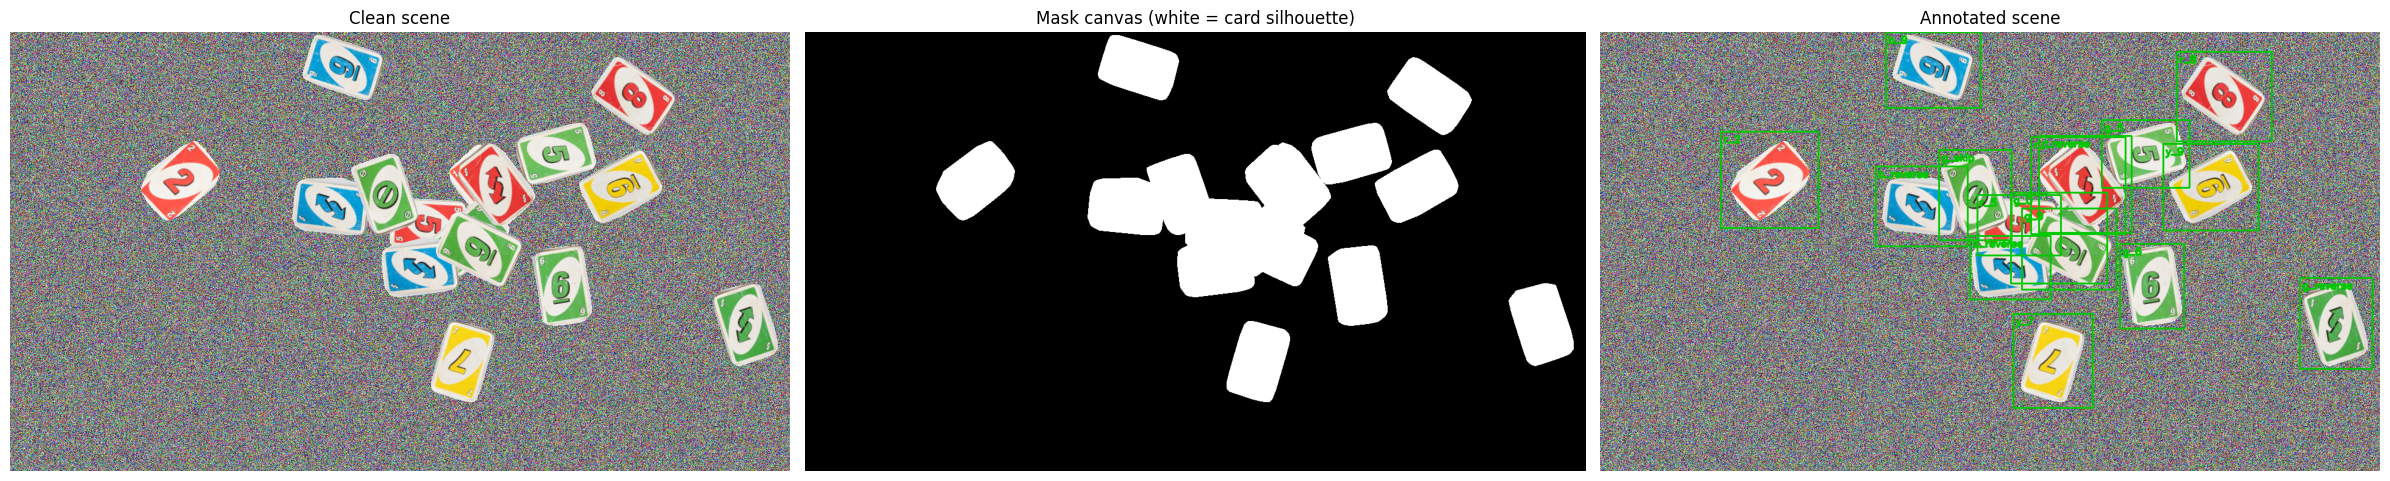

Cards placed: 16
  r_1       bbox=(707,172)-(862,331)
  r_5       bbox=(619,267)-(756,366)
  g_0       bbox=(674,263)-(832,412)
  b_reverse  bbox=(607,334)-(739,438)
  g_5       bbox=(823,144)-(967,255)
  b_reverse  bbox=(452,220)-(603,351)
  g_9       bbox=(692,289)-(847,422)
  r_8       bbox=(946,32)-(1102,179)
  r_2       bbox=(198,163)-(358,321)
  y_7       bbox=(678,462)-(808,616)
  b_9       bbox=(469,0)-(624,124)
  g_skip    bbox=(556,193)-(675,341)
  r_reverse  bbox=(720,170)-(872,329)
  y_9       bbox=(924,183)-(1080,325)
  g_reverse  bbox=(1148,403)-(1267,552)
  g_6       bbox=(853,347)-(958,486)


In [17]:
# Display one example scene + its mask
rng_demo = np.random.default_rng(7)

scene, mask_canvas, placements = make_scene(
    scene_card_images, scene_card_masks, rng_demo, scene_w=1280, scene_h=720
)

# Annotated copy with bounding boxes and labels
vis = scene.copy()
for p in placements:
    cv2.rectangle(vis, (p["x1"], p["y1"]), (p["x2"], p["y2"]), (0, 200, 0), 2)
    cv2.putText(vis, p["label"], (p["x1"] + 4, p["y1"] + 18),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 200, 0), 2, cv2.LINE_AA)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

axes[0].imshow(cv2.cvtColor(scene, cv2.COLOR_BGR2RGB))
axes[0].set_title("Clean scene")
axes[0].axis("off")

axes[1].imshow(mask_canvas, cmap="gray")
axes[1].set_title("Mask canvas (white = card silhouette)")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
axes[2].set_title("Annotated scene")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"Cards placed: {len(placements)}")
for p in placements:
    print(f"  {p['label']:8s}  bbox=({p['x1']},{p['y1']})-({p['x2']},{p['y2']})")

Saved 500 scenes  → c:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\training_data\training_images\game_snapshots
Saved 500 masks   → c:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\training_data\training_masks\game_snapshots
Saved labels             → c:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\training_data\object_labels\game_snapshots\labels.json



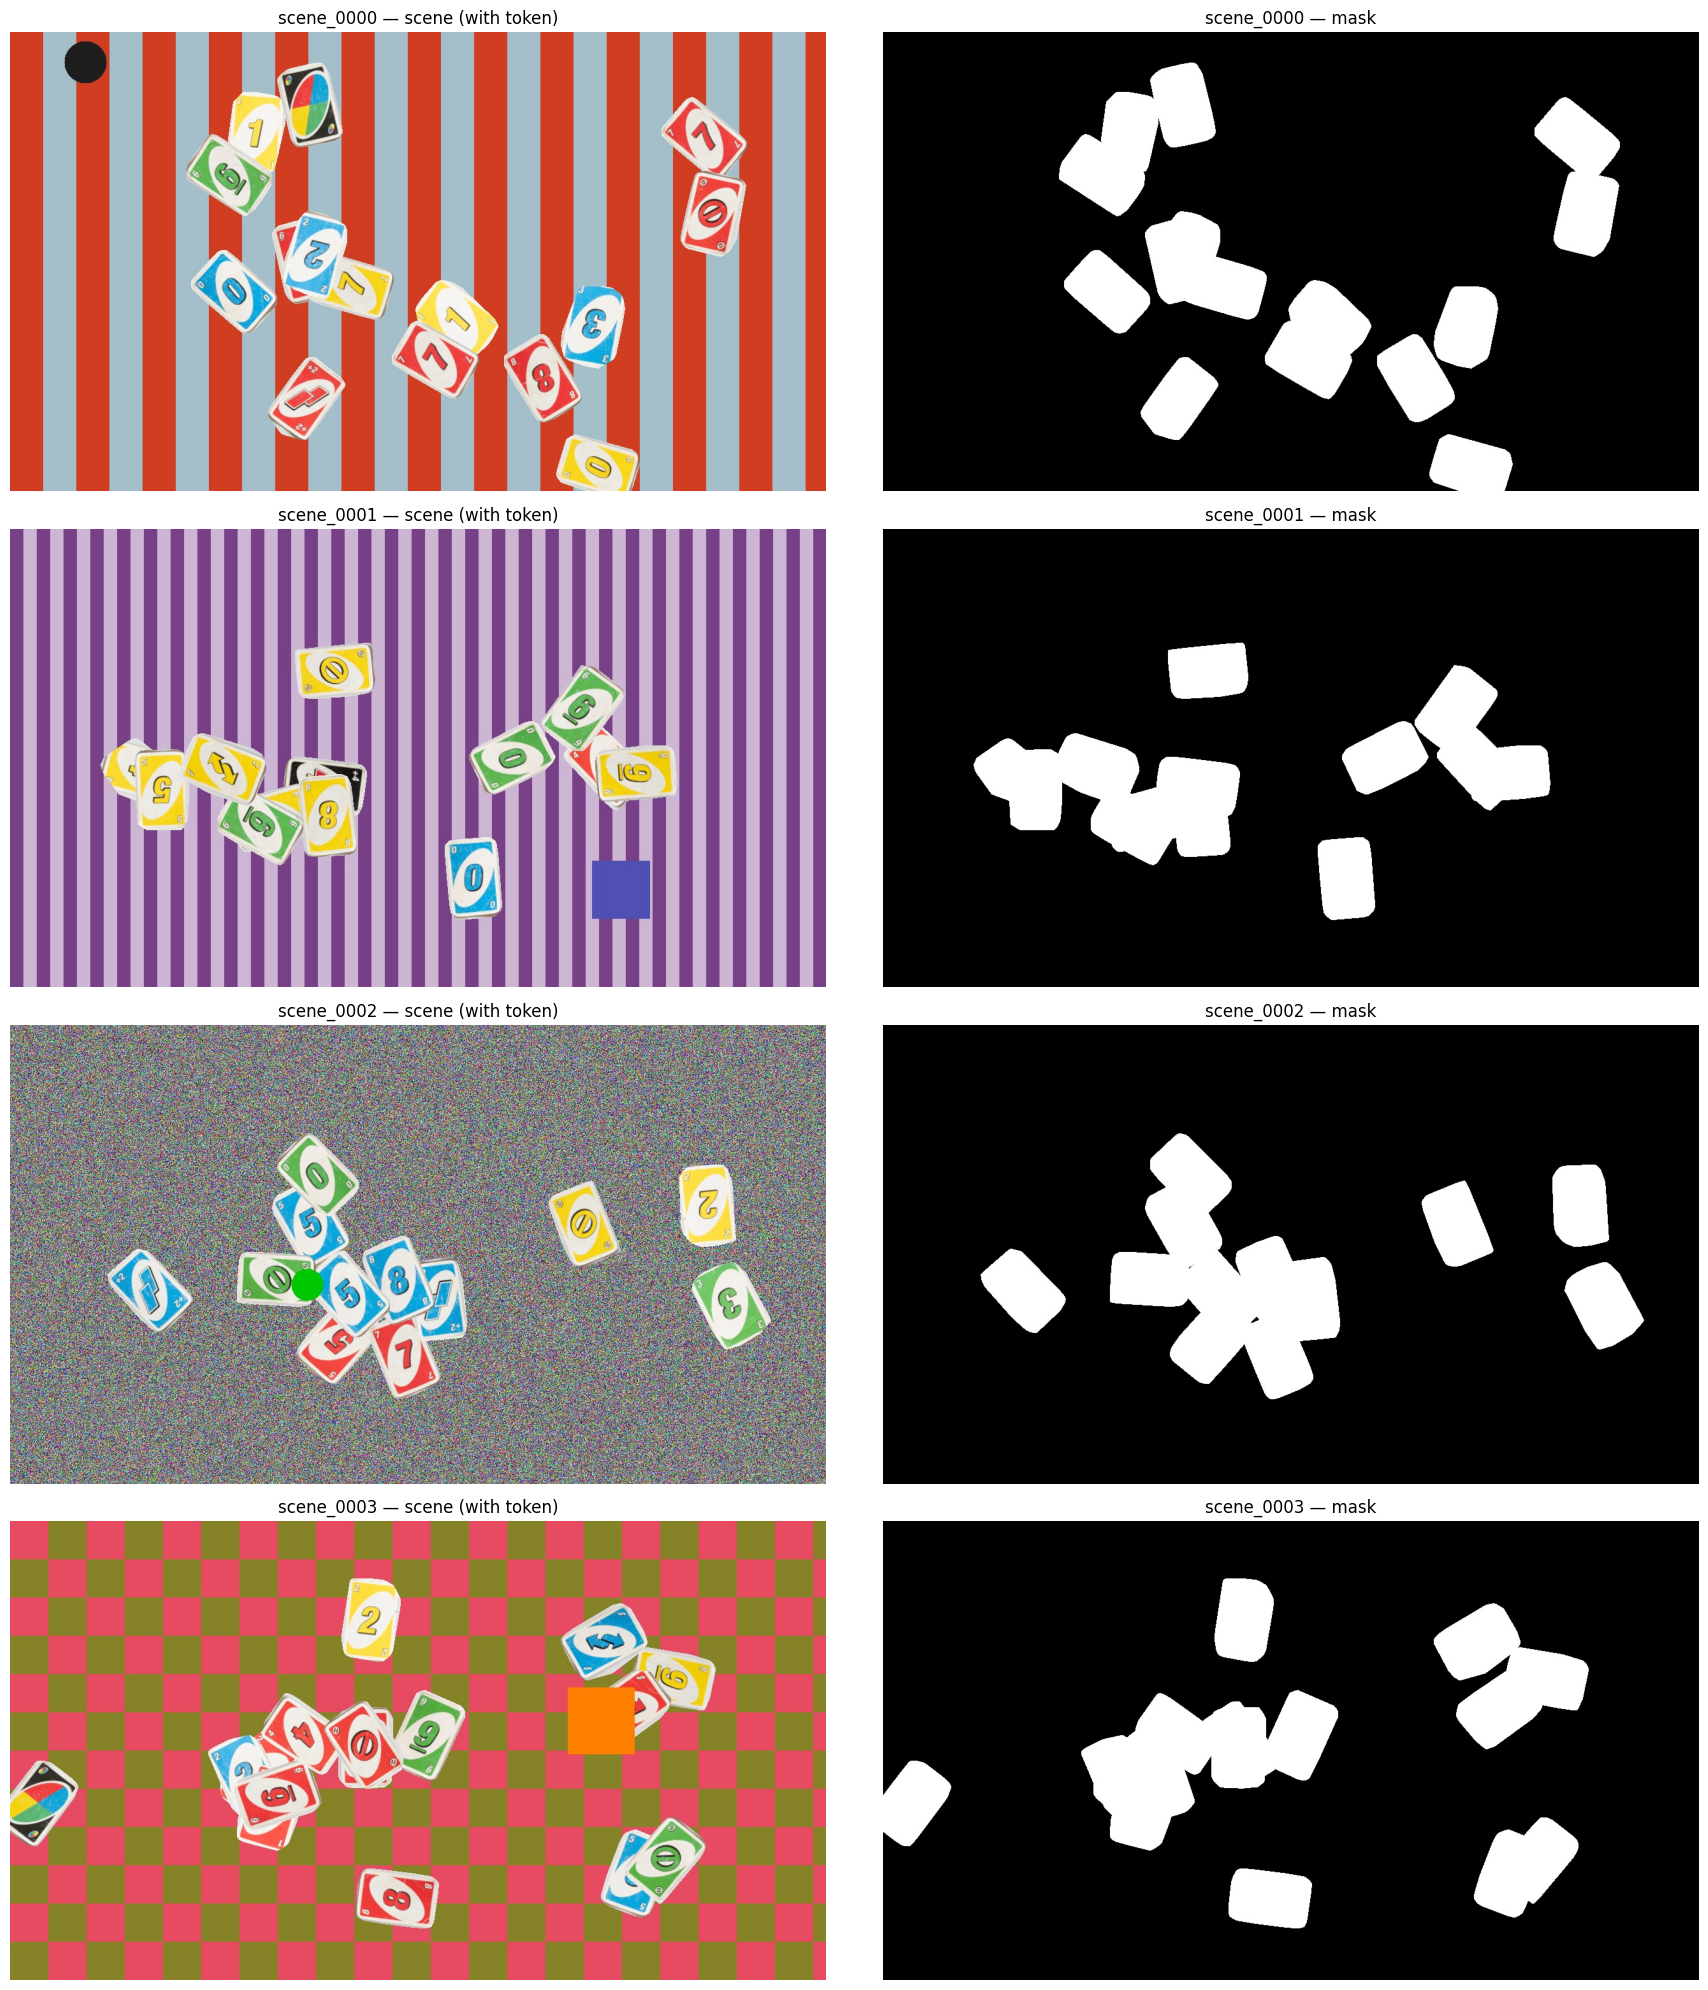

In [18]:
# Generate and save N scenes with matching masks + labels JSON.
# Each scene gets exactly one token (a single circle OR a single rectangle) pasted on top.
import json

SCENES_IMG_DIR    = os.path.join(TRAINING_DATA, "training_images", "game_snapshots")
SCENES_MASK_DIR   = os.path.join(TRAINING_DATA, "training_masks", "game_snapshots")
SCENES_LABELS_DIR = os.path.join(TRAINING_DATA, "object_labels", "game_snapshots")
N_SCENES   = 500
SCENE_W, SCENE_H = 1280, 720

os.makedirs(SCENES_IMG_DIR,    exist_ok=True)
os.makedirs(SCENES_MASK_DIR,   exist_ok=True)
os.makedirs(SCENES_LABELS_DIR, exist_ok=True)

TOKEN_COLOR_PALETTE = [
    (0, 0, 0), (30, 30, 30), (200, 0, 0), (0, 200, 0), (0, 0, 200),
    (0, 200, 200), (200, 0, 200), (200, 200, 0),
    (128, 0, 255), (0, 128, 255), (80, 180, 80), (180, 80, 80),
]
# Token radius / half-side: 3–8 % of scene height
TOKEN_SCALE_MIN, TOKEN_SCALE_MAX = 0.03, 0.08

def paste_token(canvas, rng):
    """Draw exactly one circle or rectangle on canvas in-place.
    Returns bounding box (x1, y1, x2, y2)."""
    sh, sw = canvas.shape[:2]
    color = TOKEN_COLOR_PALETTE[int(rng.integers(0, len(TOKEN_COLOR_PALETTE)))]
    size  = int(rng.uniform(TOKEN_SCALE_MIN, TOKEN_SCALE_MAX) * sh)  # radius or half-side

    if rng.random() < 0.5:
        # Circle
        cx = int(rng.integers(size, sw - size))
        cy = int(rng.integers(size, sh - size))
        cv2.circle(canvas, (cx, cy), size, color, thickness=-1)
        return cx - size, cy - size, cx + size, cy + size
    else:
        # Rectangle
        x1 = int(rng.integers(0, sw - size * 2))
        y1 = int(rng.integers(0, sh - size * 2))
        x2, y2 = x1 + size * 2, y1 + size * 2
        cv2.rectangle(canvas, (x1, y1), (x2, y2), color, thickness=-1)
        return x1, y1, x2, y2

# ── Generation loop ──────────────────────────────────────────────────────────
rng_save = np.random.default_rng(100)
all_labels_meta = []

for i in range(N_SCENES):
    sc, mc, pl = make_scene(
        scene_card_images, scene_card_masks, rng_save,
        scene_w=SCENE_W, scene_h=SCENE_H,
    )

    tx1, ty1, tx2, ty2 = paste_token(sc, rng_save)

    scene_name = f"scene_{i:04d}"
    cv2.imwrite(os.path.join(SCENES_IMG_DIR,  f"{scene_name}.jpg"), sc)
    cv2.imwrite(os.path.join(SCENES_MASK_DIR, f"{scene_name}.jpg"), mc)

    placements_meta = [
        {"label": p["label"], "x1": p["x1"], "y1": p["y1"], "x2": p["x2"], "y2": p["y2"]}
        for p in pl
    ]
    placements_meta.append({"label": "token", "x1": tx1, "y1": ty1, "x2": tx2, "y2": ty2})
    all_labels_meta.append({"scene": scene_name, "placements": placements_meta})

labels_path = os.path.join(SCENES_LABELS_DIR, "labels.json")
with open(labels_path, "w", encoding="utf-8") as f:
    json.dump(all_labels_meta, f, indent=2)

print(f"Saved {N_SCENES} scenes  → {SCENES_IMG_DIR}")
print(f"Saved {N_SCENES} masks   → {SCENES_MASK_DIR}")
print(f"Saved labels             → {labels_path}")
print()

# Quick visual summary
sample_indices = list(range(min(4, N_SCENES)))
fig, axes = plt.subplots(len(sample_indices), 2, figsize=(18, 5 * len(sample_indices)))
for row, idx in enumerate(sample_indices):
    name = f"scene_{idx:04d}"
    img  = cv2.imread(os.path.join(SCENES_IMG_DIR,  f"{name}.jpg"))
    msk  = cv2.imread(os.path.join(SCENES_MASK_DIR, f"{name}.jpg"), cv2.IMREAD_GRAYSCALE)
    axes[row, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title(f"{name} — scene (with token)")
    axes[row, 0].axis("off")
    axes[row, 1].imshow(msk, cmap="gray")
    axes[row, 1].set_title(f"{name} — mask")
    axes[row, 1].axis("off")
plt.tight_layout()
plt.show()

In [19]:
# Add horizontal (±90°) versions of every reference card to card_images / card_masks
added = 0
for label in list(card_images.keys()):
    originals_img  = list(card_images[label])   # snapshot before appending
    originals_mask = list(card_masks[label])

    for img, mask in zip(originals_img, originals_mask):
        for rot_flag in (cv2.ROTATE_90_CLOCKWISE, cv2.ROTATE_90_COUNTERCLOCKWISE):
            card_images[label].append(cv2.rotate(img,  rot_flag))
            card_masks[label].append( cv2.rotate(mask, rot_flag))
            added += 1

print(f"Added {added} rotated variants (+90° and -90°).")
print(f"Total crops now: {sum(len(v) for v in card_images.values())} "
      f"across {len(card_images)} card types.")


Added 104 rotated variants (+90° and -90°).
Total crops now: 156 across 50 card types.


In [20]:
# batch augment all crops, save images to training_images/augmented_cards/, and write aug.csv
import csv
import skimage.util

source_tags = ["L1000765", "L1000766", "L1000767", "L1000768"]
aug_dir = os.path.join(TRAINING_DATA, "training_images", "augmented_cards")
aug_csv_path = os.path.join(TRAINING_DATA, "object_labels", "augmented_cards", "aug.csv")
os.makedirs(aug_dir, exist_ok=True)
os.makedirs(os.path.dirname(aug_csv_path), exist_ok=True)

# Load labels from reference.csv: image_id -> card
ref_labels = {}
with open(REFERENCE_CSV, "r", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        img_id = row["image_id"].strip()
        card = row["card"].strip()
        if img_id:
            ref_labels[img_id] = card

def load_aligned_mask(closed_dir, crop_idx, target_h, target_w):
    mask_path = os.path.join(closed_dir, f"closed_component_{crop_idx}.jpg")
    closed_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if closed_mask is None:
        raise FileNotFoundError(f"Mask not found: {mask_path}")

    x, y, w, h = cv2.boundingRect(closed_mask)
    mask_crop = closed_mask[y:y+h, x:x+w]

    if mask_crop.shape[:2] != (target_h, target_w):
        mask_crop = cv2.resize(mask_crop, (target_w, target_h), interpolation=cv2.INTER_NEAREST)

    return mask_crop > 127

def make_pattern_variants(h, w):
    patterns = {}

    # 1) vertical stripes
    stripe_w = 12
    stripe = np.zeros((h, w, 3), dtype=np.uint8)
    for c in range(0, w, stripe_w * 2):
        stripe[:, c:c+stripe_w] = (0, 0, 255)
        stripe[:, c+stripe_w:c+2*stripe_w] = (255, 0, 0)
    patterns["pattern_stripes"] = stripe

    # 2) big rectangles
    block = 48
    rects = np.zeros((h, w, 3), dtype=np.uint8)
    for r in range(0, h, block):
        for c in range(0, w, block):
            rects[r:r+block, c:c+block] = np.random.randint(0, 256, size=3, dtype=np.uint8)
    patterns["pattern_big_rectangles"] = rects

    # 3) checkerboard
    tile = 24
    checker = np.zeros((h, w, 3), dtype=np.uint8)
    for r in range(0, h, tile):
        for c in range(0, w, tile):
            if ((r // tile) + (c // tile)) % 2 == 0:
                checker[r:r+tile, c:c+tile] = (20, 220, 120)
            else:
                checker[r:r+tile, c:c+tile] = (220, 20, 180)
    patterns["pattern_checkerboard"] = checker

    # 4) random noise pattern
    patterns["pattern_noise"] = np.random.randint(0, 256, size=(h, w, 3), dtype=np.uint8)

    return patterns

def apply_pattern_background(img_bgr, mask_fg, pattern_bgr):
    out = pattern_bgr.copy()
    out[mask_fg] = img_bgr[mask_fg]
    return out

aug_rows = []

for source_tag in source_tags:
    crops_dir  = os.path.join(REF_CARDS_DIR, source_tag, f"crops_{source_tag}")
    closed_dir = os.path.join(REF_CARDS_DIR, source_tag, f"closed_components_{source_tag}")

    if not os.path.isdir(crops_dir):
        print(f"Skipping {source_tag}: crops folder not found ({crops_dir})")
        continue

    crop_files = sorted([f for f in os.listdir(crops_dir) if f.lower().endswith(".jpg") and f.startswith("crop_")])

    for crop_file in crop_files:
        crop_idx = int(crop_file.split("_")[1].split(".")[0])
        base_id = f"{source_tag}_crop_{crop_idx}"
        card_label = ref_labels.get(base_id)
        if card_label is None:
            print(f"Skipping {base_id}: no label found in reference.csv")
            continue

        img_path = os.path.join(crops_dir, crop_file)
        img_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if img_bgr is None:
            print(f"Skipping unreadable image: {img_path}")
            continue

        h, w = img_bgr.shape[:2]

        # If mask is missing, continue with all augmentations except pattern backgrounds
        mask_fg = None
        try:
            mask_fg = load_aligned_mask(closed_dir, crop_idx, h, w)
        except FileNotFoundError as e:
            print(f"{e} -> skipping background pattern augmentations for {base_id}")

        aug_images = []

        # 1) rotation (fixed 45 degrees)
        (h, w) = img_bgr.shape[:2]
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, 45, 1.0)
        rotated_img = cv2.warpAffine(img_bgr, M, (w, h))
        aug_images.append(("rot_45", rotated_img))

        # 2) flips
        aug_images.append(("flip_vertical", cv2.flip(img_bgr, 0)))
        aug_images.append(("flip_horizontal", cv2.flip(img_bgr, 1)))

        # 3) hue change (3 small random hue shifts)
        hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
        for i in range(3):
            shift = int(np.random.choice([-12, -8, -4, 4, 8, 12]))
            hue_img = hsv.copy()
            hue_img[:, :, 0] = (hue_img[:, :, 0].astype(np.int16) + shift) % 180
            hue_bgr = cv2.cvtColor(hue_img, cv2.COLOR_HSV2BGR)
            aug_images.append((f"hue_{shift}_{i+1}", hue_bgr))

        # 4) dimmed
        aug_images.append(("dimmed", cv2.convertScaleAbs(img_bgr, alpha=0.5, beta=0)))

        # 5) less contrast
        aug_images.append(("less_contrast", cv2.convertScaleAbs(img_bgr, alpha=0.6, beta=110)))

        # 6) more contrast
        aug_images.append(("more_contrast", cv2.convertScaleAbs(img_bgr, alpha=1.5, beta=0)))

        # 7) added noise
        noisy = skimage.util.random_noise(img_bgr / 255.0, mode="speckle", var=0.08)
        noisy = np.clip(noisy * 255.0, 0, 255).astype(np.uint8)
        aug_images.append(("speckle_noise", noisy))

        # 8) squeeze and stretch
        squeezed_img = cv2.resize(img_bgr, (img_bgr.shape[1] // 2, img_bgr.shape[0]))
        squeezed_img_full = np.ones_like(img_bgr) * 255
        x_offset = (squeezed_img_full.shape[1] - squeezed_img.shape[1]) // 2
        y_offset = (squeezed_img_full.shape[0] - squeezed_img.shape[0]) // 2
        squeezed_img_full[y_offset:y_offset + squeezed_img.shape[0], x_offset:x_offset + squeezed_img.shape[1]] = squeezed_img
        aug_images.append(("squeezed", squeezed_img_full))

        stretched_wide = cv2.resize(img_bgr, (img_bgr.shape[1] * 2, img_bgr.shape[0]))
        start_x = (stretched_wide.shape[1] - img_bgr.shape[1]) // 2
        stretched_img = stretched_wide[:, start_x:start_x + img_bgr.shape[1]]
        aug_images.append(("stretched", stretched_img))

        # 9) random rectangle covers (3 different sizes, including very large)
        rect_scales = [
            (0.12, 0.25),  # small
            (0.30, 0.50),  # medium
            (0.60, 0.78),  # large (can cover around 3/4)
        ]
        for rect_i, (smin, smax) in enumerate(rect_scales, start=1):
            cover = img_bgr.copy()
            rw = int(np.random.uniform(smin, smax) * w)
            rh = int(np.random.uniform(smin, smax) * h)
            x1 = int(np.random.randint(0, max(1, w - rw + 1)))
            y1 = int(np.random.randint(0, max(1, h - rh + 1)))
            x2 = min(w, x1 + rw)
            y2 = min(h, y1 + rh)
            cv2.rectangle(cover, (x1, y1), (x2, y2), (255, 255, 255), -1)
            aug_images.append((f"white_rectangle_{rect_i}", cover))

        # 10) four pattern backgrounds outside mask (only if mask exists)
        if mask_fg is not None:
            pattern_variants = make_pattern_variants(h, w)
            for p_name, p_img in pattern_variants.items():
                aug_images.append((p_name, apply_pattern_background(img_bgr, mask_fg, p_img)))

        # 11) smaller image centered on white background
        scale = 0.7
        small_w = max(1, int(w * scale))
        small_h = max(1, int(h * scale))
        small_img = cv2.resize(img_bgr, (small_w, small_h), interpolation=cv2.INTER_AREA)
        white_canvas = np.ones_like(img_bgr) * 255
        x_offset = (w - small_w) // 2
        y_offset = (h - small_h) // 2
        white_canvas[y_offset:y_offset + small_h, x_offset:x_offset + small_w] = small_img
        aug_images.append(("small_centered", white_canvas))

        # save all augmentations and collect csv rows
        for aug_i, (aug_name, aug_img) in enumerate(aug_images, start=1):
            image_id = f"{base_id}_aug{aug_i}"
            out_path = os.path.join(aug_dir, f"{image_id}.jpg")
            cv2.imwrite(out_path, aug_img)
            aug_rows.append([image_id, card_label])

# write csv
with open(aug_csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["image_id", "card"])
    writer.writerows(aug_rows)

print(f"Loaded {len(ref_labels)} labels from: {REFERENCE_CSV}")
print(f"Saved {len(aug_rows)} augmented images to: {aug_dir}")
print(f"Saved labels CSV to: {aug_csv_path}")


Mask not found: c:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\training_data\training_images\reference_cards\L1000765\closed_components_L1000765\closed_component_8.jpg -> skipping background pattern augmentations for L1000765_crop_8
Mask not found: c:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\training_data\training_images\reference_cards\L1000765\closed_components_L1000765\closed_component_9.jpg -> skipping background pattern augmentations for L1000765_crop_9
Loaded 54 labels from: c:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\training_data\object_labels\reference_cards\reference.csv
Saved 1072 augmented images to: c:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\training_data\training_images\augmented_cards
Saved labels CSV to: c:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\training_data\object_labels\augmented_cards\aug.csv


In [21]:
# batch augment all closed masks, save to training_masks/augmented_cards/
import csv

source_tags = ["L1000765", "L1000766", "L1000767", "L1000768"]
aug_masks_dir = os.path.join(TRAINING_DATA, "training_masks", "augmented_cards")
os.makedirs(aug_masks_dir, exist_ok=True)

# Load labels from reference.csv only to mirror the exact sample filtering used for images
ref_labels = {}
with open(REFERENCE_CSV, "r", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        img_id = row["image_id"].strip()
        card = row["card"].strip()
        if img_id:
            ref_labels[img_id] = card

def load_binary_mask(closed_dir, crop_idx):
    mask_path = os.path.join(closed_dir, f"closed_component_{crop_idx}.jpg")
    m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if m is None:
        raise FileNotFoundError(f"Mask not found: {mask_path}")
    return (m > 127).astype(np.uint8) * 255

def rotate_mask(mask, angle):
    h, w = mask.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(mask, M, (w, h), flags=cv2.INTER_NEAREST, borderValue=0)

saved_masks = 0

for source_tag in source_tags:
    closed_dir = os.path.join(REF_CARDS_DIR, source_tag, f"closed_components_{source_tag}")

    if not os.path.isdir(closed_dir):
        print(f"Skipping {source_tag}: closed mask folder not found ({closed_dir})")
        continue

    closed_files = sorted([
        f for f in os.listdir(closed_dir)
        if f.lower().endswith(".jpg") and f.startswith("closed_component_")
    ])

    for closed_file in closed_files:
        crop_idx = int(closed_file.split("_")[-1].split(".")[0])
        base_id = f"{source_tag}_crop_{crop_idx}"

        if base_id not in ref_labels:
            continue

        try:
            mask = load_binary_mask(closed_dir, crop_idx)
        except FileNotFoundError as e:
            print(e)
            continue

        h, w = mask.shape[:2]
        aug_masks = []

        aug_masks.append(("rot_45", rotate_mask(mask, 45)))
        aug_masks.append(("flip_vertical", cv2.flip(mask, 0)))
        aug_masks.append(("flip_horizontal", cv2.flip(mask, 1)))

        for i in range(3):
            aug_masks.append((f"hue_copy_{i+1}", mask.copy()))

        aug_masks.append(("dimmed_copy", mask.copy()))
        aug_masks.append(("less_contrast_copy", mask.copy()))
        aug_masks.append(("more_contrast_copy", mask.copy()))
        aug_masks.append(("speckle_noise_copy", mask.copy()))

        squeezed = cv2.resize(mask, (w // 2, h), interpolation=cv2.INTER_NEAREST)
        squeezed_full = np.zeros_like(mask)
        x_offset = (w - squeezed.shape[1]) // 2
        y_offset = (h - squeezed.shape[0]) // 2
        squeezed_full[y_offset:y_offset + squeezed.shape[0], x_offset:x_offset + squeezed.shape[1]] = squeezed
        aug_masks.append(("squeezed", squeezed_full))

        stretched_wide = cv2.resize(mask, (w * 2, h), interpolation=cv2.INTER_NEAREST)
        start_x = (stretched_wide.shape[1] - w) // 2
        stretched = stretched_wide[:, start_x:start_x + w]
        aug_masks.append(("stretched", stretched))

        rect_scales = [(0.12, 0.25), (0.30, 0.50), (0.60, 0.78)]
        for rect_i, (smin, smax) in enumerate(rect_scales, start=1):
            cover = mask.copy()
            rw = int(np.random.uniform(smin, smax) * w)
            rh = int(np.random.uniform(smin, smax) * h)
            x1 = int(np.random.randint(0, max(1, w - rw + 1)))
            y1 = int(np.random.randint(0, max(1, h - rh + 1)))
            x2 = min(w, x1 + rw)
            y2 = min(h, y1 + rh)
            cv2.rectangle(cover, (x1, y1), (x2, y2), 0, -1)
            aug_masks.append((f"white_rectangle_{rect_i}", cover))

        for p_name in ["pattern_stripes", "pattern_big_rectangles", "pattern_checkerboard", "pattern_noise"]:
            aug_masks.append((p_name, mask.copy()))

        scale = 0.7
        small_w = max(1, int(w * scale))
        small_h = max(1, int(h * scale))
        small = cv2.resize(mask, (small_w, small_h), interpolation=cv2.INTER_NEAREST)
        small_full = np.zeros_like(mask)
        x_offset = (w - small_w) // 2
        y_offset = (h - small_h) // 2
        small_full[y_offset:y_offset + small_h, x_offset:x_offset + small_w] = small
        aug_masks.append(("small_centered", small_full))

        for aug_i, (_, aug_mask) in enumerate(aug_masks, start=1):
            image_id = f"{base_id}_aug{aug_i}"
            out_path = os.path.join(aug_masks_dir, f"{image_id}.jpg")
            cv2.imwrite(out_path, aug_mask)
            saved_masks += 1

print(f"Saved {saved_masks} augmented masks to: {aug_masks_dir}")


Saved 1040 augmented masks to: c:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\training_data\training_masks\augmented_cards


In [22]:
# add extra augmentations to both training_images/augmented_cards/ and training_masks/augmented_cards/ using identical names
import csv

source_tags = ["L1000765", "L1000766", "L1000767", "L1000768"]
aug_dir = os.path.join(TRAINING_DATA, "training_images", "augmented_cards")
aug_masks_dir = os.path.join(TRAINING_DATA, "training_masks", "augmented_cards")
os.makedirs(aug_dir, exist_ok=True)
os.makedirs(aug_masks_dir, exist_ok=True)

extra_rotation_angles = [20, 30, 40, 60, 80, 120, 160, 170]
rect_area_ratios = [
    ("1_2", 1 / 2),
    ("1_4", 1 / 4),
    ("1_3", 1 / 3),
    ("3_4", 3 / 4),
    ("1_8", 1 / 8),
]

ref_labels = {}
with open(REFERENCE_CSV, "r", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        img_id = row["image_id"].strip()
        card = row["card"].strip()
        if img_id:
            ref_labels[img_id] = card

def load_binary_mask(closed_dir, crop_idx):
    mask_path = os.path.join(closed_dir, f"closed_component_{crop_idx}.jpg")
    m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if m is None:
        raise FileNotFoundError(f"Mask not found: {mask_path}")
    return (m > 127).astype(np.uint8) * 255

def load_crop_image(crops_dir, crop_idx):
    img_path = os.path.join(crops_dir, f"crop_{crop_idx}.jpg")
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Image not found: {img_path}")
    return img

def rotate_mask(mask, angle):
    h, w = mask.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(mask, M, (w, h), flags=cv2.INTER_NEAREST, borderValue=0)

def rotate_image(img, angle):
    h, w = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderValue=(255, 255, 255))

def rectangle_coords(h, w, area_ratio, rng):
    target_area = max(1, int(area_ratio * h * w))
    rect_w = max(1, min(w, int(np.sqrt(target_area * (w / max(1, h))))))
    rect_h = max(1, min(h, int(target_area / max(1, rect_w))))
    rect_h = max(1, min(h, rect_h))
    rect_w = max(1, min(w, rect_w))
    x1 = int(rng.integers(0, max(1, w - rect_w + 1)))
    y1 = int(rng.integers(0, max(1, h - rect_h + 1)))
    x2 = min(w, x1 + rect_w)
    y2 = min(h, y1 + rect_h)
    return x1, y1, x2, y2

rng = np.random.default_rng(42)
saved_extra_images = 0
saved_extra_masks = 0

for source_tag in source_tags:
    crops_dir  = os.path.join(REF_CARDS_DIR, source_tag, f"crops_{source_tag}")
    closed_dir = os.path.join(REF_CARDS_DIR, source_tag, f"closed_components_{source_tag}")

    if not os.path.isdir(closed_dir):
        print(f"Skipping {source_tag}: closed mask folder not found ({closed_dir})")
        continue

    closed_files = sorted([
        f for f in os.listdir(closed_dir)
        if f.lower().endswith(".jpg") and f.startswith("closed_component_")
    ])

    for closed_file in closed_files:
        crop_idx = int(closed_file.split("_")[-1].split(".")[0])
        base_id = f"{source_tag}_crop_{crop_idx}"

        if base_id not in ref_labels:
            continue

        try:
            mask = load_binary_mask(closed_dir, crop_idx)
            img = load_crop_image(crops_dir, crop_idx)
        except FileNotFoundError as e:
            print(e)
            continue

        if img.shape[:2] != mask.shape[:2]:
            img = cv2.resize(img, (mask.shape[1], mask.shape[0]), interpolation=cv2.INTER_LINEAR)

        for angle in extra_rotation_angles:
            aug_mask = rotate_mask(mask, angle)
            aug_img = rotate_image(img, angle)
            filename = f"{base_id}_extra_rot_{angle}.jpg"
            cv2.imwrite(os.path.join(aug_masks_dir, filename), aug_mask)
            cv2.imwrite(os.path.join(aug_dir, filename), aug_img)
            saved_extra_masks += 1
            saved_extra_images += 1

        h, w = mask.shape[:2]
        for ratio_name, area_ratio in rect_area_ratios:
            x1, y1, x2, y2 = rectangle_coords(h, w, area_ratio, rng)
            aug_mask = mask.copy()
            cv2.rectangle(aug_mask, (x1, y1), (x2, y2), 0, -1)
            aug_img = img.copy()
            cv2.rectangle(aug_img, (x1, y1), (x2, y2), (255, 255, 255), -1)
            filename = f"{base_id}_extra_white_rectangle_{ratio_name}.jpg"
            cv2.imwrite(os.path.join(aug_masks_dir, filename), aug_mask)
            cv2.imwrite(os.path.join(aug_dir, filename), aug_img)
            saved_extra_masks += 1
            saved_extra_images += 1

print(f"Saved/updated {saved_extra_images} extra images in: {aug_dir}")
print(f"Saved/updated {saved_extra_masks} extra masks in: {aug_masks_dir}")


Saved/updated 676 extra images in: c:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\training_data\training_images\augmented_cards
Saved/updated 676 extra masks in: c:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\training_data\training_masks\augmented_cards


In [23]:
# Generate synthetic 'token' images: random shapes on white background, sized to match reference crops.
# Saves images -> training_images/augmented_cards/, masks -> training_masks/augmented_cards/, appends rows to aug.csv with label 'token'.
import csv
import random

source_tags = ["L1000765", "L1000766", "L1000767", "L1000768"]
aug_dir = os.path.join(TRAINING_DATA, "training_images", "augmented_cards")
aug_masks_dir = os.path.join(TRAINING_DATA, "training_masks", "augmented_cards")
aug_csv_path = os.path.join(TRAINING_DATA, "object_labels", "augmented_cards", "aug.csv")
os.makedirs(aug_dir, exist_ok=True)
os.makedirs(aug_masks_dir, exist_ok=True)

N_TOKENS_PER_CROP = 8
MIN_SHAPES = 3
MAX_SHAPES = 8

COLOR_PALETTE = [
    (0, 0, 0), (30, 30, 30), (60, 60, 60), (90, 90, 90),
    (200, 0, 0), (0, 200, 0), (0, 0, 200),
    (0, 200, 200), (200, 0, 200), (200, 200, 0),
    (128, 0, 255), (0, 128, 255), (80, 180, 80), (180, 80, 80), (255, 255, 255),
]

def draw_shape(img, mask, color):
    h, w = img.shape[:2]
    if random.random() < 0.5:
        x0 = random.randint(0, max(0, w - 2))
        y0 = random.randint(0, max(0, h - 2))
        x1 = random.randint(x0 + 1, w)
        y1 = random.randint(y0 + 1, h)
        cv2.rectangle(img,  (x0, y0), (x1, y1), color, thickness=-1)
        cv2.rectangle(mask, (x0, y0), (x1, y1), 255,   thickness=-1)
    else:
        r  = random.randint(max(3, min(h, w) // 12), max(4, min(h, w) // 4))
        cx = random.randint(r, max(r, w - r))
        cy = random.randint(r, max(r, h - r))
        cv2.circle(img,  (cx, cy), r, color, thickness=-1)
        cv2.circle(mask, (cx, cy), r, 255,   thickness=-1)

ref_labels = {}
with open(REFERENCE_CSV, "r", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        img_id = row["image_id"].strip()
        if img_id:
            ref_labels[img_id] = row["card"].strip()

print(f"ref_labels loaded: {len(ref_labels)} entries, e.g. {list(ref_labels.items())[:2]}")

token_rows = []
n_saved = 0

for source_tag in source_tags:
    crops_dir = os.path.join(REF_CARDS_DIR, source_tag, f"crops_{source_tag}")
    print(f"Checking: {crops_dir}  exists={os.path.isdir(crops_dir)}")
    if not os.path.isdir(crops_dir):
        continue

    crop_files = sorted([f for f in os.listdir(crops_dir) if f.lower().endswith(".jpg") and f.startswith("crop_")])
    print(f"  crop_files found: {len(crop_files)}, first few: {crop_files[:3]}")

    for crop_file in crop_files:
        crop_idx = int(crop_file.split("_")[1].split(".")[0])
        base_id  = f"{source_tag}_crop_{crop_idx}"

        if base_id not in ref_labels:
            continue

        sample = cv2.imread(os.path.join(crops_dir, crop_file), cv2.IMREAD_COLOR)
        if sample is None:
            continue
        h, w = sample.shape[:2]

        for k in range(N_TOKENS_PER_CROP):
            img  = np.full((h, w, 3), 255, dtype=np.uint8)
            mask = np.zeros((h, w),        dtype=np.uint8)

            for _ in range(random.randint(MIN_SHAPES, MAX_SHAPES)):
                draw_shape(img, mask, random.choice(COLOR_PALETTE))

            image_id  = f"token_{base_id}_{k}"
            cv2.imwrite(os.path.join(aug_dir,       f"{image_id}.jpg"), img)
            cv2.imwrite(os.path.join(aug_masks_dir, f"{image_id}.jpg"), mask)
            token_rows.append([image_id, "token"])
            n_saved += 1

with open(aug_csv_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerows(token_rows)

print(f"Saved {n_saved} token images to:  {aug_dir}")
print(f"Saved {n_saved} token masks  to:  {aug_masks_dir}")
print(f"Appended {len(token_rows)} rows (label='token') to: {aug_csv_path}")


ref_labels loaded: 54 entries, e.g. [('L1000765_crop_0', 'y_3'), ('L1000765_crop_1', 'y_2')]
Checking: c:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\training_data\training_images\reference_cards\L1000765\crops_L1000765  exists=True
  crop_files found: 12, first few: ['crop_0.jpg', 'crop_1.jpg', 'crop_10.jpg']


Checking: c:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\training_data\training_images\reference_cards\L1000766\crops_L1000766  exists=True
  crop_files found: 12, first few: ['crop_0.jpg', 'crop_1.jpg', 'crop_10.jpg']
Checking: c:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\training_data\training_images\reference_cards\L1000767\crops_L1000767  exists=True
  crop_files found: 14, first few: ['crop_0.jpg', 'crop_1.jpg', 'crop_10.jpg']
Checking: c:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\training_data\training_images\reference_cards\L1000768\crops_L1000768  exists=True
  crop_files found: 16, first few: ['crop_0.jpg', 'crop_1.jpg', 'crop_10.jpg']
Saved 432 token images to:  c:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\training_data\training_images\augmented_cards
Saved 432 token masks  to:  c:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\training_data\training_masks\augmented_cards
Appended 432 rows (label='token') to:

In [26]:
# Generate game_snapshots with the real median background instead of synthetic backgrounds.
# Output folder: training_data/training_images/game_snapshots_funky_bg/
# Masks and labels go to the same sibling dirs as the regular game_snapshots.
import json

CHALLENGE_DIR  = os.path.join(PROJECT, "..", "data", "iapr-26-uno-vision-challenge")
CHALLENGE_DIR  = os.path.normpath(CHALLENGE_DIR)
MEDIAN_BG_PATH = os.path.join(CHALLENGE_DIR, "high_quality_median_background.png")

FUNKY_IMG_DIR    = os.path.join(TRAINING_DATA, "training_images",  "game_snapshots_funky_bg")
FUNKY_MASK_DIR   = os.path.join(TRAINING_DATA, "training_masks",   "game_snapshots_funky_bg")
FUNKY_LABELS_DIR = os.path.join(TRAINING_DATA, "object_labels",    "game_snapshots_funky_bg")
os.makedirs(FUNKY_IMG_DIR,    exist_ok=True)
os.makedirs(FUNKY_MASK_DIR,   exist_ok=True)
os.makedirs(FUNKY_LABELS_DIR, exist_ok=True)

# Load the median background once
median_bg_full = cv2.imread(MEDIAN_BG_PATH)
if median_bg_full is None:
    raise FileNotFoundError(f"Median background not found: {MEDIAN_BG_PATH}")
print(f"Loaded median background: {median_bg_full.shape[1]}x{median_bg_full.shape[0]}")

N_FUNKY   = 500
SCENE_W_F = 1280
SCENE_H_F = 720

# Resize background to match scene dimensions (once)
median_bg = cv2.resize(median_bg_full, (SCENE_W_F, SCENE_H_F), interpolation=cv2.INTER_LINEAR)

def make_scene_funky_bg(card_images_dict, card_masks_dict, rng):
    """Like make_scene but always uses median_bg as the background (no mask for bg).
    The mask_canvas only covers the card silhouettes, not the background."""
    canvas      = median_bg.copy()   # fresh copy of the real background
    mask_canvas = np.zeros((SCENE_H_F, SCENE_W_F), dtype=np.uint8)

    card_h  = max(1, int(CARD_SCALE * SCENE_H_F))
    n_cards = int(rng.integers(12, 21))
    labels  = list(card_images_dict.keys())
    placements = []

    for _ in range(n_cards):
        label    = labels[rng.integers(0, len(labels))]
        card_idx = int(rng.integers(0, len(card_images_dict[label])))
        src_img  = card_images_dict[label][card_idx]
        src_mask = card_masks_dict[label][card_idx]

        scale   = card_h / max(1, src_img.shape[0])
        card_w  = max(1, int(src_img.shape[1] * scale))
        img_rs  = cv2.resize(src_img,  (card_w, card_h), interpolation=cv2.INTER_AREA)
        mask_rs = cv2.resize(src_mask, (card_w, card_h), interpolation=cv2.INTER_NEAREST)

        angle  = float(rng.uniform(0, 360))
        rad    = np.radians(angle)
        cos_a, sin_a = abs(np.cos(rad)), abs(np.sin(rad))
        rot_w  = int(card_h * sin_a + card_w * cos_a) + 2
        rot_h  = int(card_h * cos_a + card_w * sin_a) + 2

        cx, cy  = card_w / 2, card_h / 2
        rot_mat = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
        rot_mat[0, 2] += (rot_w / 2 - cx)
        rot_mat[1, 2] += (rot_h / 2 - cy)

        img_rot  = cv2.warpAffine(img_rs,  rot_mat, (rot_w, rot_h),
                                  flags=cv2.INTER_LINEAR,
                                  borderMode=cv2.BORDER_CONSTANT, borderValue=(255, 255, 255))
        mask_rot = cv2.warpAffine(mask_rs, rot_mat, (rot_w, rot_h),
                                  flags=cv2.INTER_NEAREST,
                                  borderMode=cv2.BORDER_CONSTANT, borderValue=0)

        footprint = np.zeros((rot_h, rot_w), dtype=np.uint8)
        contours, _ = cv2.findContours(mask_rot, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            all_pts = np.concatenate(contours, axis=0)
            hull    = cv2.convexHull(all_pts)
            cv2.fillPoly(footprint, [hull], 255)
        else:
            continue

        ch, cw = img_rot.shape[:2]
        cx_scene = int(rng.normal(loc=SCENE_W_F * 0.50, scale=SCENE_W_F * 0.20))
        cy_scene = int(rng.normal(loc=SCENE_H_F * 0.50, scale=SCENE_H_F * 0.20))
        x1 = cx_scene - cw // 2;  y1 = cy_scene - ch // 2
        x2 = x1 + cw;             y2 = y1 + ch

        src_x1 = max(0, -x1);  src_y1 = max(0, -y1)
        dst_x1 = max(0,  x1);  dst_y1 = max(0,  y1)
        dst_x2 = min(SCENE_W_F, x2);  dst_y2 = min(SCENE_H_F, y2)
        src_x2 = src_x1 + (dst_x2 - dst_x1)
        src_y2 = src_y1 + (dst_y2 - dst_y1)

        if dst_x2 <= dst_x1 or dst_y2 <= dst_y1:
            continue

        fp_patch    = footprint[src_y1:src_y2, src_x1:src_x2]
        img_patch   = img_rot  [src_y1:src_y2, src_x1:src_x2]
        card_pixels = fp_patch > 127

        canvas[dst_y1:dst_y2, dst_x1:dst_x2][card_pixels]      = img_patch[card_pixels]
        mask_canvas[dst_y1:dst_y2, dst_x1:dst_x2][card_pixels] = 255

        placements.append(dict(label=label, card_idx=card_idx,
                               x1=dst_x1, y1=dst_y1, x2=dst_x2, y2=dst_y2))

    return canvas, mask_canvas, placements

# ── Generation loop ───────────────────────────────────────────────────────────
rng_funky = np.random.default_rng(200)
all_funky_meta = []

for i in range(N_FUNKY):
    sc, mc, pl = make_scene_funky_bg(scene_card_images, scene_card_masks, rng_funky)

    tx1, ty1, tx2, ty2 = paste_token(sc, rng_funky)

    scene_name = f"scene_{i:04d}"
    cv2.imwrite(os.path.join(FUNKY_IMG_DIR,  f"{scene_name}.jpg"), sc)
    cv2.imwrite(os.path.join(FUNKY_MASK_DIR, f"{scene_name}.jpg"), mc)

    placements_meta = [
        {"label": p["label"], "x1": p["x1"], "y1": p["y1"], "x2": p["x2"], "y2": p["y2"]}
        for p in pl
    ]
    placements_meta.append({"label": "token", "x1": tx1, "y1": ty1, "x2": tx2, "y2": ty2})
    all_funky_meta.append({"scene": scene_name, "placements": placements_meta})

labels_path = os.path.join(FUNKY_LABELS_DIR, "labels.json")
with open(labels_path, "w", encoding="utf-8") as f:
    json.dump(all_funky_meta, f, indent=2)

print(f"Saved {N_FUNKY} funky-bg scenes  → {FUNKY_IMG_DIR}")
print(f"Saved {N_FUNKY} funky-bg masks   → {FUNKY_MASK_DIR}")
print(f"Saved labels                     → {labels_path}")

Loaded median background: 1280x852
Saved 500 funky-bg scenes  → c:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\training_data\training_images\game_snapshots_funky_bg
Saved 500 funky-bg masks   → c:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\training_data\training_masks\game_snapshots_funky_bg
Saved labels                     → c:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\training_data\object_labels\game_snapshots_funky_bg\labels.json
